In [5]:
import math
import datetime
import numpy as np
import xarray as xr
import netCDF4 as nc
import matplotlib.pyplot as plt

mkdir -p failed for path /home/grace/.config/matplotlib: [Errno 20] Not a directory: '/home/grace/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-2hcpv6qc because there was an issue with the default path (/home/grace/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Bresenham Line Algorithm, which selects discrete cells to best approximate a line

In [6]:
def plotLineLow(x0, x1, y0, y1):
    ii, jj = [], []
    dx, dy = x1 -x0, y1 - y0    
    
    yi, y, D = 1, y0, (2*dy) - dx
    
    if dy < 0:
        yi = -1
        dy = -dy

    for x in range(x0, x1):
        ii.append(x)
        jj.append(y)
        if D > 0:
            y = y+yi
            D = D+(2*(dy-dx))
            ii.append(x)
            jj.append(y)
        else:
            D = D+2*dy
    return ii, jj

def plotLineHigh(x0, x1, y0, y1):
    ii = []
    jj = []

    dx = x1 - x0
    dy = y1 - y0
    
    xi = 1
    if dx < 0:
        xi = -1
        dx = -dx
    D = (2*dx) - dy
    x = x0

    for y in range(y0, y1):
        ii.append(x)
        jj.append(y)
        if D > 0:
            x = x+xi
            D = D + (2*(dx-dy))
            ii.append(x)
            jj.append(y)
        else:
            D = D + 2*dx
    return ii, jj

def section_calculation(x0, x1, y0, y1):
    
    if abs(y1-y0) < abs(x1-x0):
        if x0 > x1:
            ii, jj = plotLineLow(x1, x0, y1, y0)
        else:
            ii, jj = plotLineLow(x0, x1, y0, y1)
    else:
            if y0 > y1:
                ii, jj = plotLineHigh(x1, x0, y1, y0)
            else:
                ii, jj = plotLineHigh(x0, x1, y0, y1)
    return ii, jj

will try two transects (one nortwest-southeast and one northeast-southwest)
1: (0,0,310:320,180:210)
2: (0,0,

In [218]:
def t_test(ii,jj):
    mask = np.zeros((30, 30))
    a = np.arange(0,30,1)
    b = np.arange(0,30,1)
    
    for n in range(0,len(ii)-1):
        i1 = int(ii[n])
        i2 = int(ii[n+1])
        j1 = int(jj[n])
        j2 = int(jj[n+1])
        
        #T: are we going south or west?
        negative=False
        if a[j1] > a[j2]: negative = True #south
        if a[i1] > a[i2]: negative = True #west
        
        if negative == False: continue #just want the southward component for davis strait
        
        #T: so we should only either have i change or j change
        if j1 == j2: # G: if the movement to the next cell is purely horizontal, choose v at this point
        
            #comp.append('v')
            
            #vt = dv['vomecrty']
            #v = vt.isel(y=j1, x=i1)
            mask[j1,i1] +=1
        
        elif i1 == i1: # G: otherwise (if movement to next cell is purely vertical) choose u at this point
            #T: change in x
            #comp.append('u')
            #vt = du['vozocrtx']
            #v = vt.isel(y=j1, x=i1)
    
            mask[j1, i1] +=2
    return mask

In [223]:
def t_exp(ii,jj):
    mask = np.zeros((30, 30))
    
    for n in range(0,len(ii)-1):
        i1, i2, j1, j2 = int(ii[n]), int(ii[n+1]), int(jj[n]), int(jj[n+1])
        

        if j1 == j2: # G: if the movement to the next cell is purely horizontal
            mask[j1,i1] +=1 # choose v at this point
        
        elif i1 == i2: # G: otherwise (if movement to next cell is purely vertical) choose u at this point
            mask[j1-1, i1] +=2 # j1 - 1 for northeast flow
    return mask

In [224]:
ii, jj = section_calculation(0, 29,11, 1)

Text(0.5, 0.01, 'flow coming from the northeast')

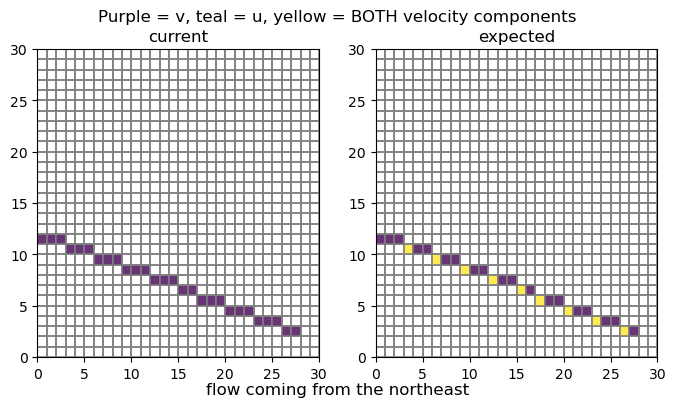

In [225]:
mask_t = t_test(ii,jj)
mask_exp = t_exp(ii,jj)

fig, axes = plt.subplots(1,2, figsize=(8,4))
axes[0].pcolormesh(np.where(mask_t!=0, mask_t, np.nan), vmin = 1, vmax = 3, alpha=.8, edgecolor='grey',linewidth=.003)
axes[1].pcolormesh(np.where(mask_exp!=0, mask_exp, np.nan), vmin = 1, vmax = 3, alpha=.8, edgecolor = 'grey', linewidth=.003)
axes[0].set_title('current')
axes[1].set_title('expected')
fig.suptitle('Purple = v, teal = u, yellow = BOTH velocity components')
fig.supxlabel('flow coming from the northeast')

In [221]:
ii, jj = section_calculation(1, 29,1, 29)

Text(0.5, 0.01, 'flow coming from the northwest')

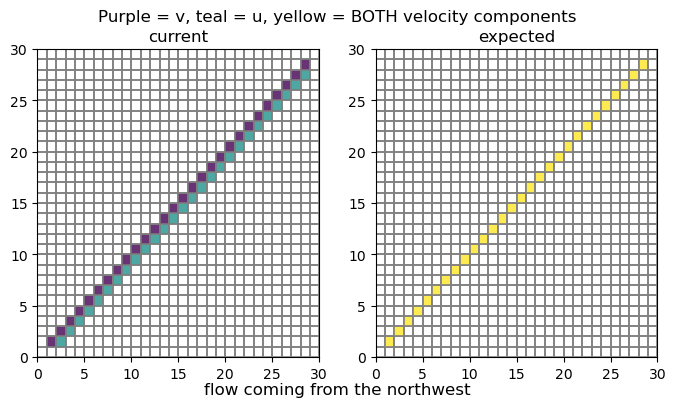

In [222]:
mask_t = t_test(ii,jj)
mask_exp = t_exp(ii,jj)

fig, axes = plt.subplots(1,2, figsize=(8,4))
axes[0].pcolormesh(np.where(mask_t!=0, mask_t, np.nan), vmin = 1, vmax = 3, alpha=.8, edgecolor='grey',linewidth=.003)
axes[1].pcolormesh(np.where(mask_exp!=0, mask_exp, np.nan), vmin = 1, vmax = 3, alpha=.8, edgecolor = 'grey', linewidth=.003)
axes[0].set_title('current')
axes[1].set_title('expected')
fig.suptitle('Purple = v, teal = u, yellow = BOTH velocity components')
fig.supxlabel('flow coming from the northwest')

Text(0.5, 0.01, 'flow coming from the southeast')

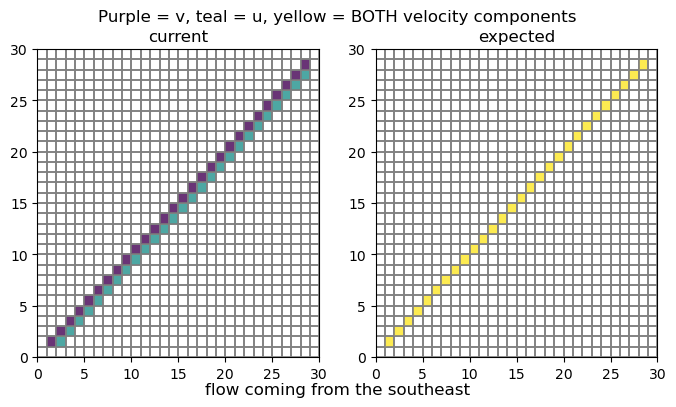

In [211]:
mask_t = t_test(ii,jj)
mask_exp = t_exp(ii,jj)

fig, axes = plt.subplots(1,2, figsize=(8,4))
axes[0].pcolormesh(np.where(mask_t!=0, mask_t, np.nan), vmin = 1, vmax = 3, alpha=.8, edgecolor='grey',linewidth=.003)
axes[1].pcolormesh(np.where(mask_exp!=0, mask_exp, np.nan), vmin = 1, vmax = 3, alpha=.8, edgecolor = 'grey', linewidth=.003)
axes[0].set_title('current')
axes[1].set_title('expected')
fig.suptitle('Purple = v, teal = u, yellow = BOTH velocity components')
fig.supxlabel('flow coming from the southeast')